In [1]:
## FEATURE SELECTION

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE

# Load the cleaned and engineered data
df = pd.read_csv('../data/train_cleaned.csv')


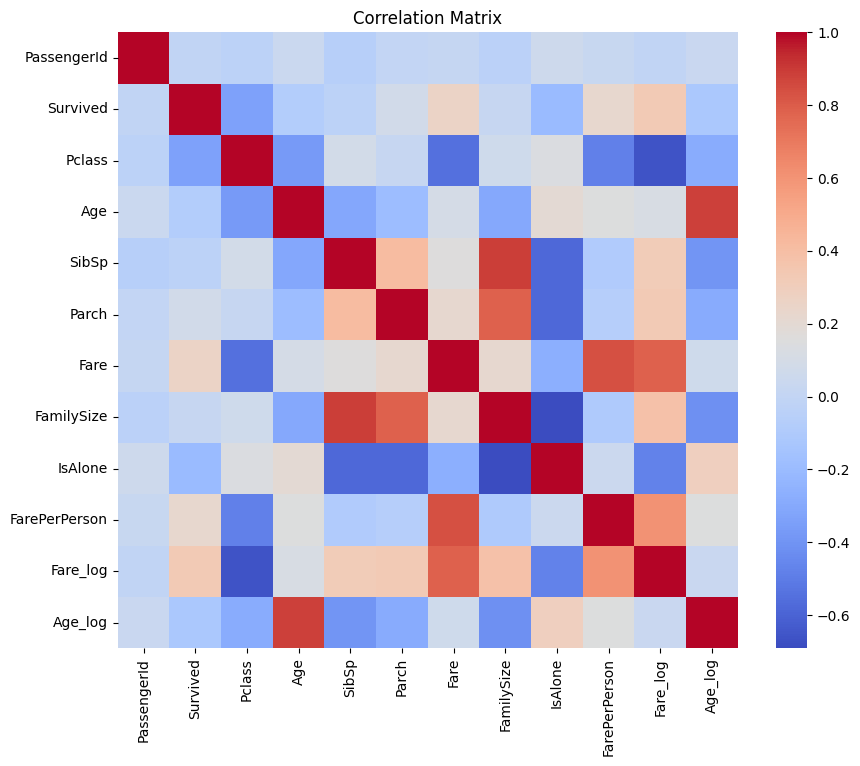

In [2]:
# Identify numerical columns for correlation

cols_to_check = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(10, 8))
sns.heatmap(df[cols_to_check].corr(), annot=False, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


In [4]:
# Feature Importance using random forest

# Define features (X) and target (y)
# Drop columns that aren't useful for math (like names/IDs)
# 1. Define target
y = df['Survived']

# 2. Define features by dropping the target AND all text-heavy/ID columns
# We drop 'Name', 'Ticket', and 'Cabin' because they contain strings like 'C85'
X = df.drop(columns=['Survived', 'PassengerId', 'Name', 'Ticket', 'Cabin'], errors='ignore')

# 3. Ensure all remaining categorical columns are encoded
# If you haven't done this yet, this line converts 'Sex', 'Embarked', etc., into numbers
X = pd.get_dummies(X, drop_first=True)

# 4. Now try to train the model again
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

print("Success! The model is trained.")



Success! The model is trained.


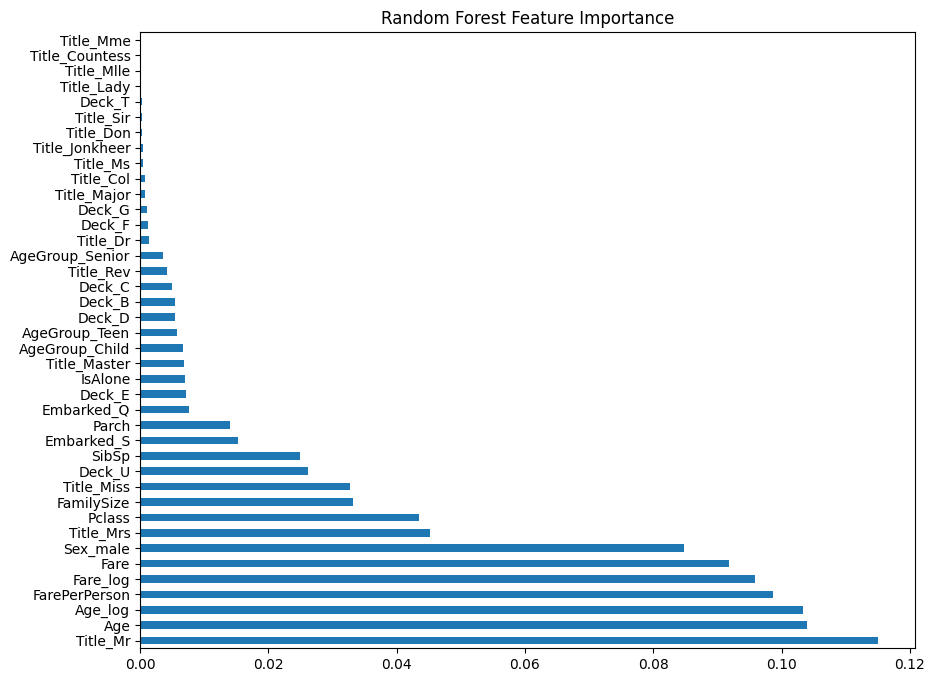

In [5]:
# Rank and Plot
features = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
features.plot(kind='barh')
plt.title("Random Forest Feature Importance")
plt.show()